In [8]:
#Import Libraries

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

In [7]:
#Load Dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\Malli Mounika\Downloads\ml_resume_dataset_4500.csv")
df

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
0,1,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support,False,Sales professional with strong communication s...,0
1,2,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant,False,Sales professional with strong communication s...,0
2,3,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer,True,Research scientist with strong statistical bac...,1
3,4,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator,True,Customer support representative with some Exce...,0
4,5,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support,False,Content creator interested in data science but...,0
...,...,...,...,...,...,...,...,...,...
4495,4496,Sumaiya Majumder,2.0,Bachelors,"Pandas, Azure",Receptionist,False,Receptionist experienced in communication and ...,0
4496,4497,Badhan Islam,4.0,Bachelors,"XGBoost, Computer Vision, Feature Engineering,...",Customer Support,False,Receptionist experienced in communication and ...,0
4497,4498,Niloy Ahmed,0.0,Bachelors,"SQL, Machine Learning, EDA, Seaborn, XGBoost, ...",Telecaller,False,Marketing intern with experience in social med...,0
4498,4499,Mitu Uddin,3.0,Bachelors,"Spark, PyTorch, OpenCV, SQLAlchemy, Git, Strea...",Office Assistant,False,Customer support representative with some Exce...,0


In [9]:
df.describe()

,id,years_experience,label
count,4500.000000,4500.000000,4500.000000
mean,2250.500000,4.437778,0.300000
std,1299.182435,3.653459,0.458308
min,1.000000,0.000000,0.000000
25%,1125.750000,1.000000,0.000000
50%,2250.500000,4.000000,0.000000
75%,3375.250000,7.000000,1.000000
max,4500.000000,15.000000,1.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4500 non-null   int64  
 1   name              4500 non-null   object 
 2   years_experience  4500 non-null   float64
 3   highest_degree    4500 non-null   object 
 4   skills            4500 non-null   object 
 5   current_title     4500 non-null   object 
 6   has_portfolio     4500 non-null   bool   
 7   raw_text          4500 non-null   object 
 8   label             4500 non-null   int64  
dtypes: bool(1), float64(1), int64(2), object(5)
memory usage: 285.8+ KB


In [11]:
#Handle Missing Values

df.isnull().sum()

id                  0
name                0
years_experience    0
highest_degree      0
skills              0
current_title       0
has_portfolio       0
raw_text            0
label               0
dtype: int64

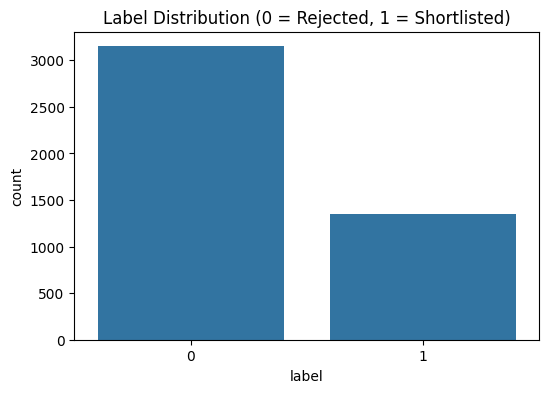

In [12]:
# Cell 3: Label distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title('Label Distribution (0 = Rejected, 1 = Shortlisted)')
plt.show()

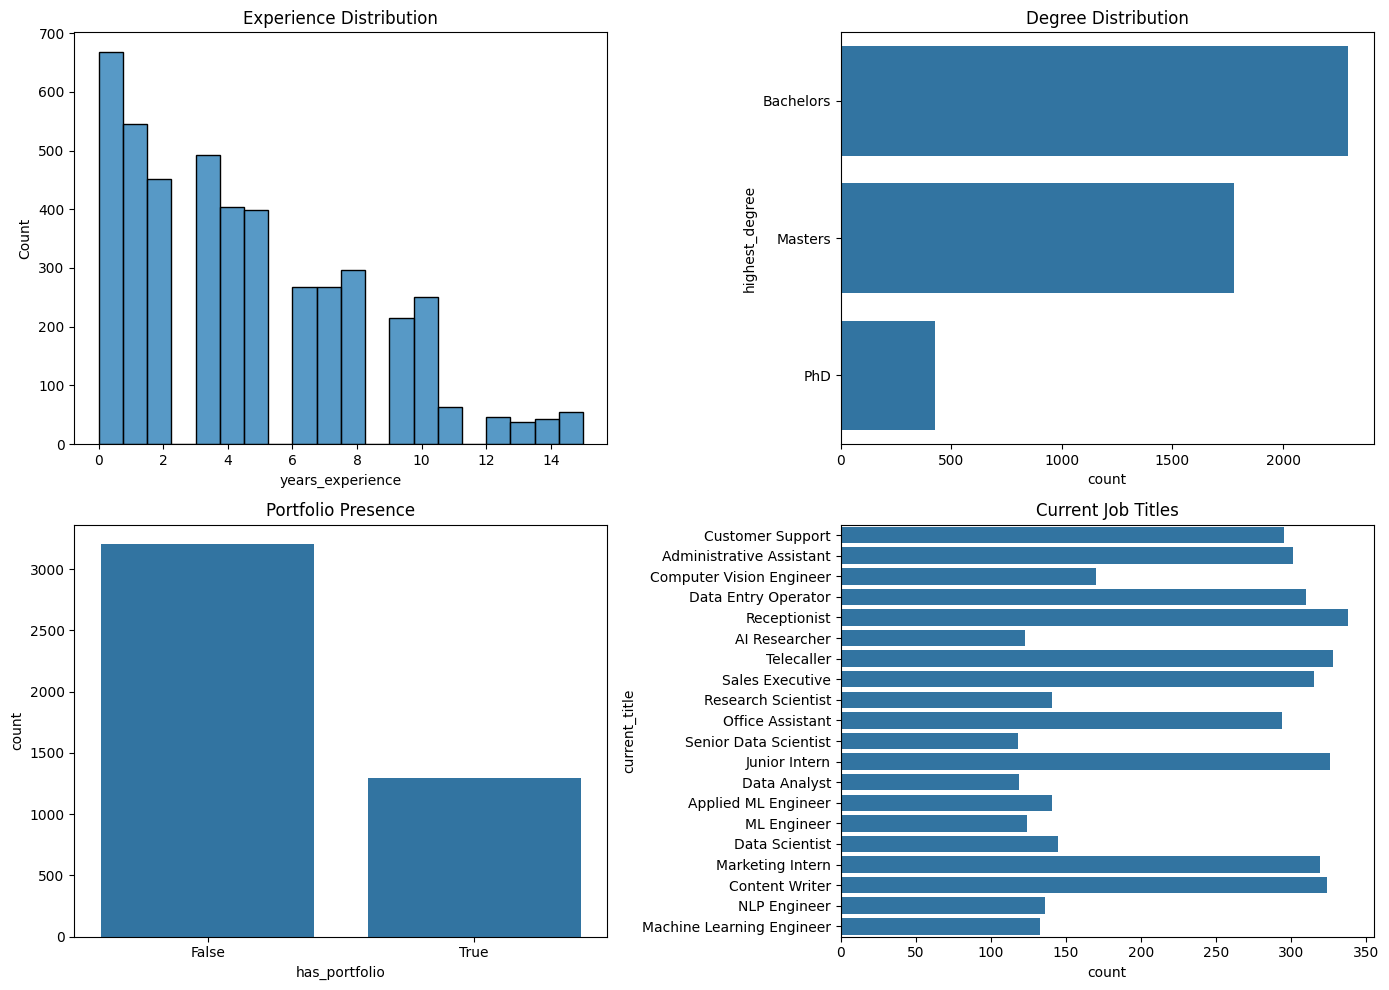

In [13]:
# Cell 4: Panel EDA
fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.histplot(df['years_experience'], bins=20, ax=axes[0,0])
axes[0,0].set_title('Experience Distribution')
sns.countplot(y=df['highest_degree'], ax=axes[0,1])
axes[0,1].set_title('Degree Distribution')
sns.countplot(x=df['has_portfolio'], ax=axes[1,0])
axes[1,0].set_title('Portfolio Presence')
sns.countplot(y=df['current_title'], ax=axes[1,1])
axes[1,1].set_title('Current Job Titles')
plt.tight_layout()
plt.show()

In [14]:
# Cell 5: Feature Engineering
from sklearn.preprocessing import LabelEncoder                

df['combined_text'] = (
 df['raw_text'].fillna('') + ' ' +
 df['skills'].fillna('') + ' ' +
 df['current_title'].fillna('')
)
df['skill_count'] = df['skills'].apply(lambda x:len(str(x).split(',')))
degree_encoder = LabelEncoder()
df['highest_degree'] =degree_encoder.fit_transform(df['highest_degree'])


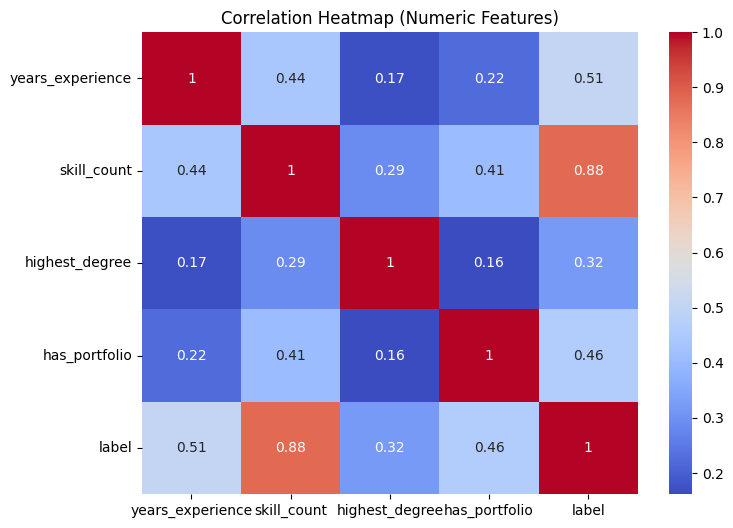

In [15]:
#cell 6 :correlation map

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns

plt.figure(figsize=(8,6))
corr = df[["years_experience","skill_count","highest_degree","has_portfolio","label"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [16]:
# Cell 7: Train-test split
from sklearn.model_selection import train_test_split
X_text = df['combined_text']
X_num = df[['years_experience', 'skill_count', 'highest_degree',
'has_portfolio']]
y = df['label']
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test =train_test_split(X_text, X_num, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
# Cell 8: TF-IDF + Numeric feature scaling

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.sparse import hstack
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf = tfidf.transform(X_text_test)
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)
X_train = hstack([X_train_tfidf, X_num_train_scaled])
X_test = hstack([X_test_tfidf, X_num_test_scaled])

In [18]:
# Cell 9: Train models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
RandomForestClassifier(n_estimators=200, random_state=42)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
# Cell 10: Model comparison

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score, confusion_matrix
from scipy.sparse import hstack
models = {'Logistic Regression': lr, 'Random Forest': rf}
for name, model in models.items():
 preds = model.predict(X_test)
 probs = model.predict_proba(X_test)[:,1]
 print(f'\n{name}')
 print('Accuracy:', accuracy_score(y_test, preds))
 print('ROC-AUC:', roc_auc_score(y_test, probs))


Logistic Regression
Accuracy: 1.0
ROC-AUC: 1.0

Random Forest
Accuracy: 1.0
ROC-AUC: 1.0


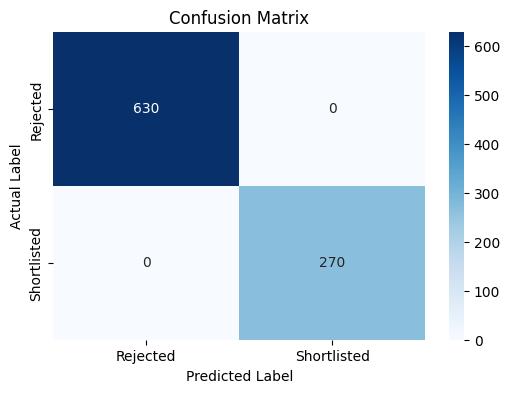

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [20]:
#cell 11 :Confusion matrix
model = lr # choose model here (lr or rf)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
 cm, annot=True, fmt="d", cmap="Blues",
 xticklabels=["Rejected", "Shortlisted"],
 yticklabels=["Rejected", "Shortlisted"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test, y_pred))

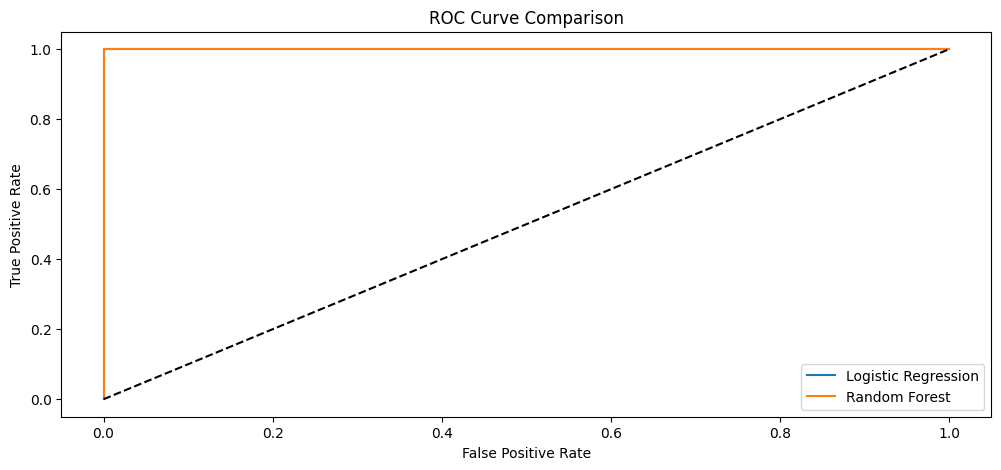

In [23]:
# Cell 12: ROC curve
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score,roc_curve, confusion_matrix
plt.figure(figsize=(12,5))
for name, model in models.items():
 probs = model.predict_proba(X_test)[:,1]
 fpr, tpr, _ = roc_curve(y_test, probs)
 plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

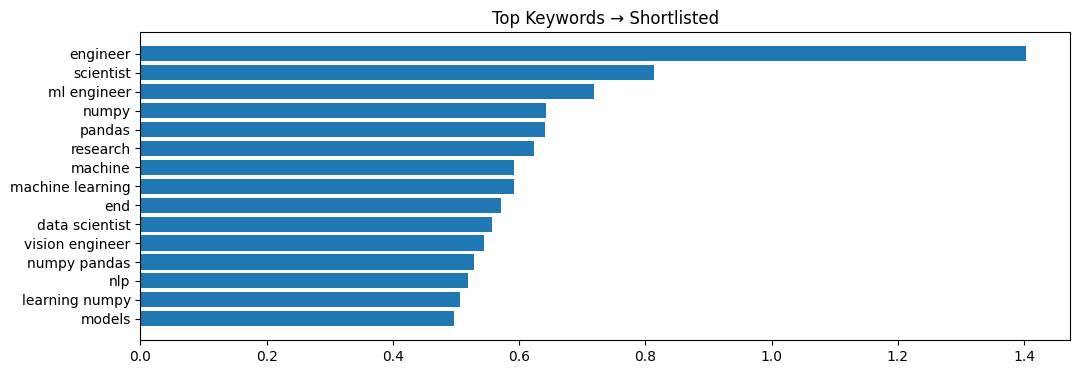

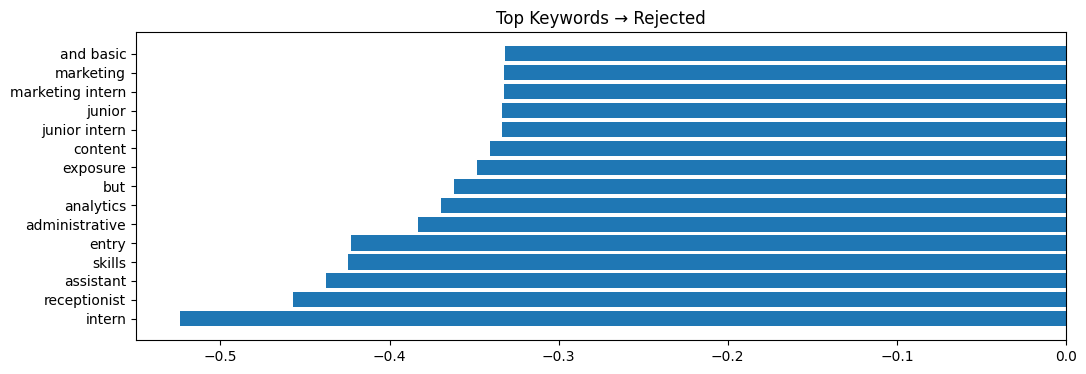

In [24]:
# Cell 13: Top keywords influencing shortlist vs reject

feature_names = np.array(tfidf.get_feature_names_out())
coef = lr.coef_[0][:len(feature_names)]
top_positive = feature_names[np.argsort(coef)[-15:]]
top_negative = feature_names[np.argsort(coef)[:15]]
plt.figure(figsize=(12,4))
plt.barh(top_positive, sorted(coef)[-15:])
plt.title('Top Keywords → Shortlisted')
plt.show()
plt.figure(figsize=(12,4))
plt.barh(top_negative, sorted(coef)[:15])
plt.title('Top Keywords → Rejected')
plt.show()

In [25]:
# Cell 14: Predict single resume with probability visualization

def predict_resume(text, num_features):
 vec = tfidf.transform([text])
 num_scaled = scaler.transform([num_features])
 combined = hstack([vec, num_scaled])
 prob = lr.predict_proba(combined)[0]

 plt.bar(['Rejected','Shortlisted'], prob)
 plt.title('Resume Shortlist Probability')
 plt.show()

 return prob

In [26]:
# Cell 15: Rank multiple candidates

def rank_candidates(df):
 df['degree_score'] = df['highest_degree'].map({
 'Bachelors': 1,
 'Masters': 2,
 'PhD': 3
 }).fillna(0)
 df['shortlist_score'] = (
 df['degree_score'] * 0.3 +
 df['years_experience'] * 0.4
 )
 return df.sort_values('shortlist_score', ascending=False)

In [27]:
# Cell 16: Score all resumes & show Top 10

df_scored = rank_candidates(df.copy())
df_scored[['current_title','shortlist_score']].head(10)

,current_title,shortlist_score
888,Research Scientist,6.0
4214,Computer Vision Engineer,6.0
4202,NLP Engineer,6.0
66,Machine Learning Engineer,6.0
1274,Computer Vision Engineer,6.0
4101,NLP Engineer,6.0
1425,Computer Vision Engineer,6.0
1270,AI Researcher,6.0
4142,Research Scientist,6.0
1873,Applied ML Engineer,6.0


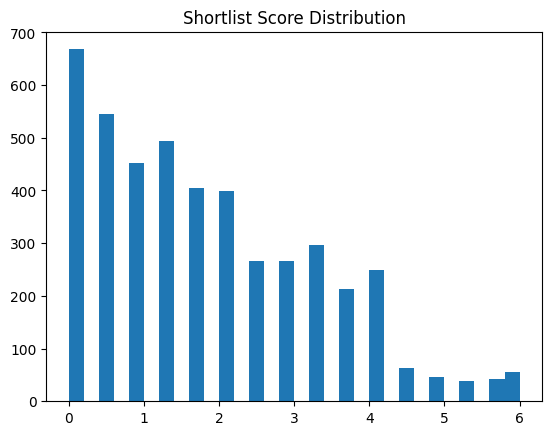

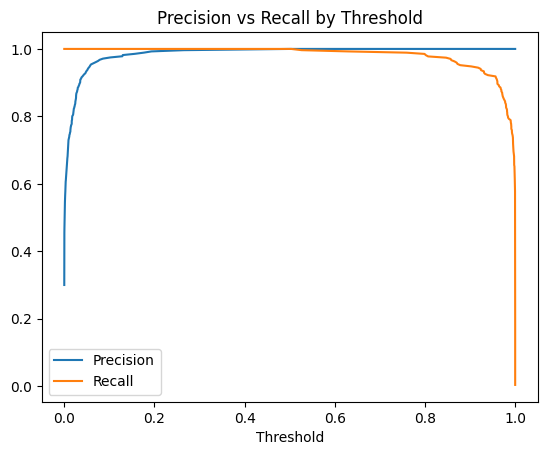

In [28]:
# Cell 17: Score distribution & Precision-Recall analysis

from sklearn.metrics import precision_recall_curve
scores = df_scored['shortlist_score']
plt.hist(scores, bins=30)
plt.title('Shortlist Score Distribution')
plt.show()
precision, recall, thresholds = precision_recall_curve(y_test,
lr.predict_proba(X_test)[:,1])
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.legend()
plt.title('Precision vs Recall by Threshold')
plt.xlabel('Threshold')
plt.show()